In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

# Plot styling defaults
FONT_FAMILY = "Arial"
TITLE_SIZE = 22
AXIS_TITLE_SIZE = 16
TICK_SIZE = 13
LEGEND_SIZE = 13

In [10]:
carewear_path = Path("/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_Carehub_CareWear/DATASET/CareWear_heart_rate_quality_features.csv")
galaxy_path = Path("/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_Carehub_CareWear/DATASET/GalaxyPPG_heart_rate_quality_features.csv")
new_dataset_path = Path("/Volumes/SS/Project_CareWear/DATASET/ss_drive/ZENODO_PROJECT/data/quality_reports/heart_rate_quality_features.csv")
# ---- Load Data ----
carewear = pd.read_csv(carewear_path)
carewear["Dataset"] = "CareWear"

galaxy = pd.read_csv(galaxy_path)
galaxy["Dataset"] = "GalaxyPPG"

new_data = pd.read_csv(new_dataset_path)
new_data["Dataset"] = "Behavioural IoT"


# ---- Combine ----
df = pd.concat([carewear, galaxy, new_data], ignore_index=True)

print("Datasets loaded:")
print(df["Dataset"].value_counts())

Datasets loaded:
Dataset
GalaxyPPG          439
CareWear           233
Behavioural IoT    129
Name: count, dtype: int64


In [11]:
galaxy.columns

Index(['FileName', 'Participant', 'Activity', 'Total Samples', 'Outliers',
       'Percentage Outliers', 'Flatlines', 'HR Range: 0–40 bpm',
       'HR Range: 40–60 bpm', 'HR Range: 60–80 bpm', 'HR Range: 80–100 bpm',
       'HR Range: 100–120 bpm', 'HR Range: 120–140 bpm',
       'HR Range: 140–160 bpm', 'HR Range: 160–180 bpm',
       'HR Range: 180–200 bpm', 'HR Range: >200 bpm', 'Sample Rate Penalty',
       'Quality Score', 'Dataset'],
      dtype='object')

In [12]:
metrics = [
    "Percentage Outliers",
    "Flatlines",
    "HR Range: 0–40 bpm",
    'HR Range: >200 bpm'
]

In [13]:
summary = (
    df.groupby("Dataset")[metrics]
    .mean()
    .round(3)
    .reset_index()
)

summary

,Dataset,Percentage Outliers,Flatlines,HR Range: 0–40 bpm,HR Range: >200 bpm
0,Behavioural IoT,2.877,11.310,14.434,0.000
1,CareWear,6.073,65.429,76.009,0.182
2,GalaxyPPG,16.610,36.689,45.053,0.000


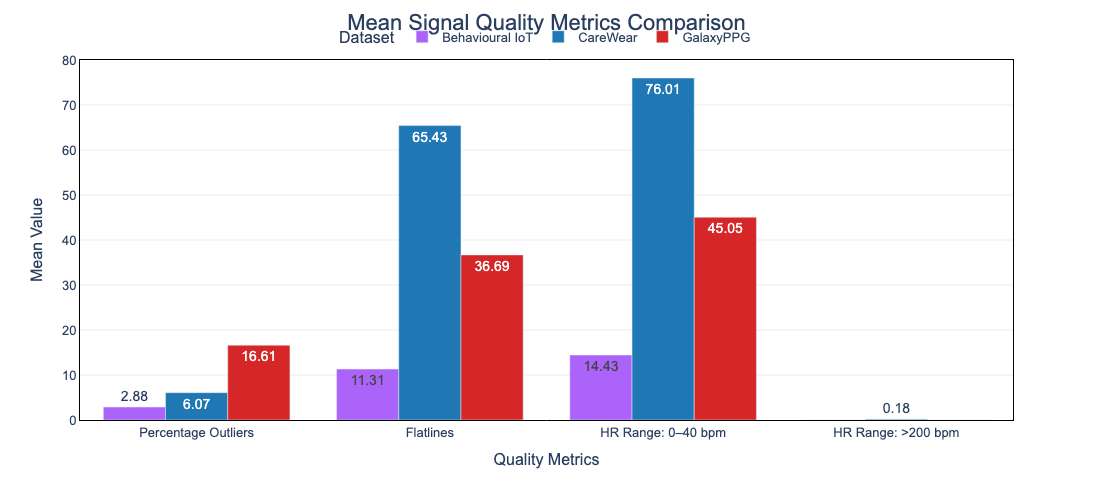

In [25]:
# ---- Define consistent dataset colors ----
DATASET_COLORS = {
    "CareWear": "#1f77b4",
    "GalaxyPPG": "#d62728",
    "New Dataset": "#2ca02c"   # modify if needed
}

fig = px.bar(
    summary.melt(id_vars="Dataset"),
    x="variable",
    y="value",
    color="Dataset",
    barmode="group",
    text_auto=".2f",
    color_discrete_map=DATASET_COLORS
)

fig.update_layout(
    # Centered title
    title=dict(
        text="Mean Signal Quality Metrics Comparison",
        x=0.5,
        xanchor="center",
        font=dict(size=TITLE_SIZE)
    ),

    font=dict(family=FONT_FAMILY, size=14),

    xaxis_title="Quality Metrics",
    yaxis_title="Mean Value",

    # Horizontal legend below title
    legend=dict(
        title="Dataset",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(size=LEGEND_SIZE),

        # Transparent legend background
        bgcolor="rgba(0,0,0,0)",
        bordercolor="rgba(0,0,0,0)"
    ),

    # ACM paper style
    plot_bgcolor="white",
    paper_bgcolor="white",

    height=500
)

# ACM-style axes
fig.update_xaxes(
    title_font_size=AXIS_TITLE_SIZE,
    tickfont_size=TICK_SIZE,
    showgrid=False,
    linecolor="black",
    mirror=True
)

fig.update_yaxes(
    title_font_size=AXIS_TITLE_SIZE,
    tickfont_size=TICK_SIZE,
    showgrid=True,
    gridcolor="rgba(0,0,0,0.08)",
    linecolor="black",
    mirror=True
)

fig.show()

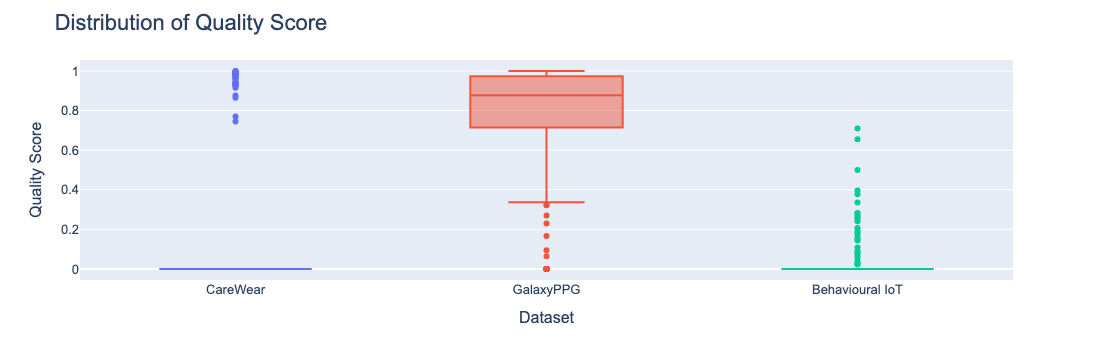

In [15]:
import plotly.graph_objects as go

def boxplot_metric(metric):
    fig = px.box(
        df,
        x="Dataset",
        y=metric,
        color="Dataset",
        points="outliers",
    )

    fig.update_layout(
        title=f"Distribution of {metric}",
        title_font_size=TITLE_SIZE,
        font=dict(family=FONT_FAMILY),
        xaxis_title="Dataset",
        yaxis_title=metric,
        showlegend=False
    )

    fig.update_xaxes(title_font_size=AXIS_TITLE_SIZE, tickfont_size=TICK_SIZE)
    fig.update_yaxes(title_font_size=AXIS_TITLE_SIZE, tickfont_size=TICK_SIZE)

    fig.show()

# Try one:
boxplot_metric("Quality Score")

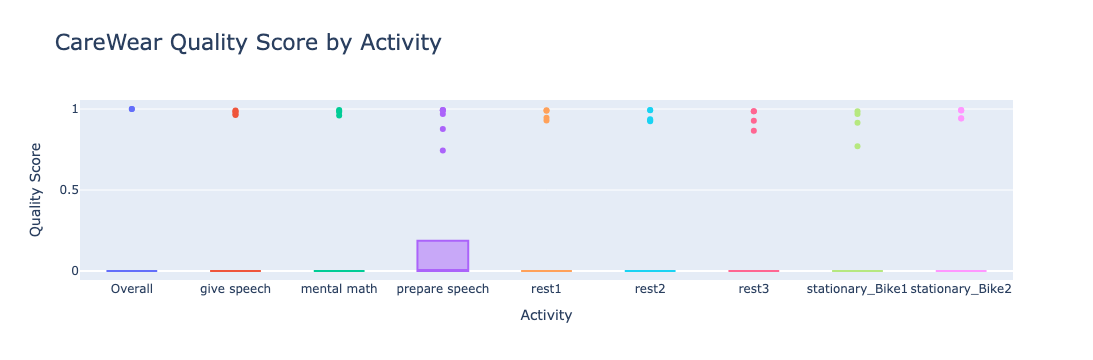

In [16]:
if "Activity" in carewear.columns:
    fig = px.box(
        carewear,
        x="Activity",
        y="Quality Score",
        color="Activity",
        title="CareWear Quality Score by Activity",
    )

    fig.update_layout(
        title_font_size=TITLE_SIZE,
        xaxis_title="Activity",
        yaxis_title="Quality Score",
        showlegend=False
    )

    fig.show()

### Create summary table

In [27]:
pip install tabulate


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd

# 1. Define your files and labels here
# You can easily add more files to this list
files = {
    "CareWear": "/Volumes/SS/Project_CareWear/DATASET/ss_drive/4_merged_lables/quality_reports/heart_rate_quality_features_CareWear.csv",
    "GalaxyPPG": "/Volumes/SS/Project_CareWear/DATASET/ss_drive/GalaxyPPG/Merged_HR/quality_reports/heart_rate_quality_features.csv",
    # "Wearable Behavioural IoT": "your_file_name.csv"
}

def compute_overall_summary(file_dict):
    all_dataset_stats = {}
    
    # Mapping for cleaner labels to match your example table
    rename_map = {
        "Outliers": "Outliers (count)",
        "Percentage Outliers": "Outliers (%)",
        "HR Range: 0–40 bpm": "HR 0–40 bpm",
        "HR Range: 40–60 bpm": "HR 40–60 bpm",
        "HR Range: 60–80 bpm": "HR 60–80 bpm",
        "HR Range: 80–100 bpm": "HR 80–100 bpm",
        "HR Range: 100–120 bpm": "HR 100–120 bpm",
        "HR Range: 120–140 bpm": "HR 120–140 bpm",
        "HR Range: 140–160 bpm": "HR 140–160 bpm",
        "HR Range: 160–180 bpm": "HR 160–180 bpm",
        "HR Range: 180–200 bpm": "HR 180–200 bpm",
        "HR Range: >200 bpm": "HR >200 bpm"
    }

    for label, filepath in file_dict.items():
        # Load the CSV
        df = pd.read_csv(filepath)
        
        # Subset by Activity = 'Overall'
        overall_df = df[df['Activity'] == 'Overall']
        
        # Count participants (N)
        n_participants = df['Participant'].nunique()
        column_header = f"{label} (N={n_participants})"
        
        # Identify numeric feature columns (exclude IDs and metadata)
        exclude = ['FileName', 'Participant', 'Activity']
        features = [col for col in df.columns if col not in exclude]
        
        dataset_stats = {}
        for col in features:
            mean_val = overall_df[col].mean()
            std_val = overall_df[col].std()
            
            # Format as Mean ± SD
            display_name = rename_map.get(col, col)
            dataset_stats[display_name] = f"{mean_val:.2f} ± {std_val:.2f}"
            
        all_dataset_stats[column_header] = dataset_stats

    # Convert results into a structured DataFrame
    summary_df = pd.DataFrame(all_dataset_stats)
    return summary_df

# Generate the table
final_summary = compute_overall_summary(files)

# Display for copy-pasting
# Use .to_markdown() for a clean look in Jupyter or just display(final_summary)
print(final_summary.to_markdown())

# Optional: Export to Excel directly
# final_summary.to_excel("Summary_Table_Activity_Overall.xlsx")

|                         | CareWear (N=29)           | GalaxyPPG (N=21)   |
|:------------------------|:--------------------------|:-------------------|
| Total Samples           | 50377.69 ± 49364.50       | 3843.48 ± 74.77    |
| Sample Rate (Hz)        | 4.84 ± 4.21               | 1.00 ± 0.00        |
| Sample Rate Consistency | 0.02 ± 0.09               | 0.91 ± 0.01        |
| Outliers (count)        | 8734.34 ± 15338.42        | 534.38 ± 272.31    |
| Outliers (%)            | 16.90 ± 11.27             | 13.85 ± 6.91       |
| Flatlines               | 10636.28 ± 19707.49       | 436.43 ± 182.34    |
| Flatline %              | 16.70 ± 12.24             | 11.32 ± 4.61       |
| Flatline Duration (sec) | -6155649.38 ± 24335733.78 | 438.29 ± 183.73    |
| Sample Rate Penalty     | 0.98 ± 0.09               | 0.09 ± 0.01        |
| Quality Score           | 0.01 ± 0.07               | 0.68 ± 0.10        |
| HR 0–40 bpm             | 8731.31 ± 15333.66        | 534.38 ± 272.31    |